In [ ]:
# from pathlib import Path
# import pandas as pd

# user_anime_df = pd.read_csv("../data/UserAnimeList.csv")

Data Cleaning & Memory Optimization for user_anime_df

In [ ]:
# user_anime_df['my_score'] = user_anime_df['my_score'].astype('int8')
# user_anime_df['my_status'] = user_anime_df['my_status'].astype('int8')
# user_anime_df['anime_id'] = pd.to_numeric(user_anime_df['anime_id'], downcast='integer')
# user_anime_df.shape

(80076112, 11)

In [ ]:
# user_anime_df_completed = user_anime_df[user_anime_df['my_status'] == 2]
# user_anime_df_filtered = user_anime_df_completed[["username", "anime_id", "my_score"]]
# user_anime_df_filtered.shape

(50445526, 3)

In [ ]:
# display(sum(user_anime_df_filtered["my_score"].isna()))
# display(sum(user_anime_df_filtered["anime_id"].isna()))
# display(sum(user_anime_df_filtered["username"].isna()))

0

0

158

In [ ]:
# user_anime_df_filtered.dropna(inplace=True)
# display(sum(user_anime_df["username"].isna()))

0

In [ ]:
# user_anime_df_filtered.to_parquet("../data/user_anime_df.parquet", engine="pyarrow", compression="snappy")

Read in Processed Data

In [ ]:
import pandas as pd
user_anime_df = pd.read_parquet("../data/user_anime_df.parquet", engine="pyarrow")
user_df = pd.read_csv("../data/UserList.csv")

Data preprocessing

In [95]:
import numpy as np
snapshot_year = 2018 # when the dataset was created
birth_years = pd.to_numeric(user_df['birth_date'].astype(str).str[:4], errors='coerce')
join_years = pd.to_numeric(user_df['join_date'].astype(str).str[:4], errors='coerce')

calculated_age = snapshot_year - birth_years
invalid_birth = (birth_years > join_years) | (birth_years > snapshot_year)
user_df['age'] = np.where(invalid_birth, np.nan, calculated_age)

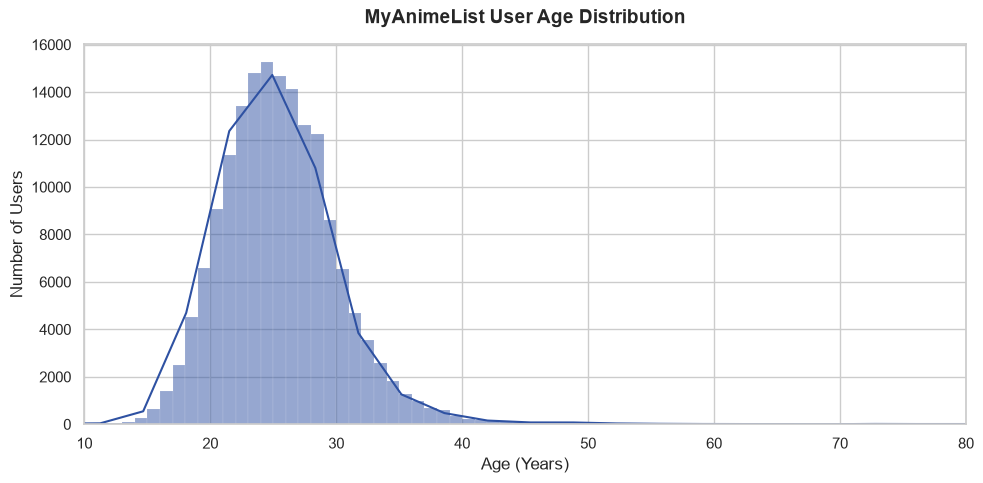

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style and MAL-inspired brand color
sns.set_theme(style="whitegrid")
mal_blue = "#2e51a2" 

# Create the figure
plt.figure(figsize=(10, 5), dpi=100)

# Plot histogram with a Kernel Density Estimate (KDE) line
sns.histplot(
    data=user_df, 
    x='age', 
    bins=int(user_df['age'].max() - user_df['age'].min()), 
    kde=True, 
    color=mal_blue,
    edgecolor='white'
)

# Labeling and styling
plt.title('MyAnimeList User Age Distribution', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Age (Years)', fontsize=12)
plt.ylabel('Number of Users', fontsize=12)
plt.xlim(10, 80)  # Limits to reasonable age ranges to focus on the core user base

# Clean up layout and display
plt.tight_layout()
plt.show()


Before removing over 60 (Mean: 25.4, Median: 25, Std: 7.2)

After  removing over 60 (Mean: 25.0, Median: 25, Std: 4.7)

In [97]:
# Convert any age over 60 to NaN
user_df['age'] = np.where((user_df['age'] > 60) | (user_df['age'] < 10), np.nan, user_df['age'])

# Print updated metrics to verify
print("New Cleaned Mean:", user_df['age'].mean())
print("New Cleaned Median:", user_df['age'].median())
print("New Cleaned Std:", user_df['age'].std())

New Cleaned Mean: 25.08568961278058
New Cleaned Median: 25.0
New Cleaned Std: 4.710531887385849


In [98]:
# Bin users into meaningful lifestyle categories
age_bins = [0, 17, 24, 34, 60]
age_labels = ['Teens (<18)', 'College/Young Adult (18-24)', 'Working Adult (25-34)', 'Older Fan (35+)']

user_df['age_group'] = pd.cut(user_df['age'], bins=age_bins, labels=age_labels, right=False)
user_df = pd.get_dummies(user_df, columns=['age_group'], dummy_na=True, dtype=int)
user_df

,username,user_id,user_watching,user_completed,user_onhold,user_dropped,user_plantowatch,user_days_spent_watching,gender,location,...,last_online,stats_mean_score,stats_rewatched,stats_episodes,age,age_group_Teens (<18),age_group_College/Young Adult (18-24),age_group_Working Adult (25-34),age_group_Older Fan (35+),age_group_nan
0,karthiga,2255153,3,49,1,0,0,55.31,Female,"Chennai, India",...,2014-02-04 01:32:00,7.43,0.0,3391.0,28.0,0,0,1,0,0
1,RedvelvetDaisuki,1897606,61,396,39,0,206,118.07,Female,Manila,...,1900-05-13 02:47:00,6.78,80.0,7094.0,23.0,0,1,0,0,0
2,Damonashu,37326,45,195,27,25,59,83.70,Male,"Detroit,Michigan",...,1900-03-24 12:48:00,6.15,6.0,4936.0,27.0,0,0,1,0,0
3,bskai,228342,25,414,2,5,11,167.16,Male,"Nayarit, Mexico",...,2014-05-12 16:35:00,8.27,1.0,10081.0,28.0,0,0,1,0,0
4,shuzzable,2347781,36,72,16,2,25,35.48,NaN,NaN,...,2015-09-09 21:54:00,9.06,7.0,2154.0,NaN,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
302670,ScruffyPuffy,3119025,0,27,0,0,0,7.92,NaN,NaN,...,2014-10-10 09:04:00,0.00,0.0,477.0,NaN,0,0,0,0,1
302671,Torasori,3975907,22,239,0,4,176,86.88,Male,"Latvia, Riga",...,2018-05-24 21:34:46,8.98,47.0,5313.0,20.0,0,1,0,0,0
302672,onpc,1268417,5,169,2,5,24,38.36,Male,NaN,...,2016-12-28 14:35:00,7.72,0.0,2280.0,NaN,0,0,0,0,1
302673,HMicca,1289601,11,73,2,2,16,119.97,Female,"Birmingham, England",...,2012-11-15 08:10:00,8.89,11.0,7049.0,23.0,0,1,0,0,0


Do join date